Social Media Comment Analysis


In [22]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import LatentDirichletAllocation

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

 Collect Social Media Comments (Simulated Data)



In [23]:
data = {
    'text': [
        "This new smartphone is absolutely amazing! The camera is incredible. #productlaunch",
        "Product X is a total rip-off. My old one was much better. #disappointed",
        "The marketing campaign for the new soda is so creative! Love the ads. #refreshing",
        "Battery life on the new laptop is terrible. Regret this purchase. #techissues",
        "Just tried the new coffee flavor, it's surprisingly good! Highly recommend. #coffeelover",
        "Another boring campaign from this brand. They need fresh ideas. #marketingfail",
        "This software update fixed all the bugs, finally! Smooth experience now. #greatupdate",
        "Customer service was unhelpful and rude. I'm taking my business elsewhere. #badservice",
        "Excited for the upcoming game release! Pre-ordered it already. #gaming",
        "The price for Product Y is way too high for what it offers. Overpriced. #budget",
        "Loving the new eco-friendly packaging! Great step forward. #sustainability",
        "My order arrived damaged. Very frustrated with the delivery. #deliveryfail",
        "This influencer marketing is getting out of hand. Too many sponsored posts. #ads",
        "The quality of these new shoes is fantastic. Worth every penny. #fashion",
        "The product launch event was well-organized and informative. Good job! #event",
        "Still waiting for my refund. This delay is unacceptable. #poorcustomerservice",
        "Best product of the year! Revolutionary design and performance. #innovation",
        "The app keeps crashing after the latest update. Unusable. #buggyapp",
        "Such a fun contest they are running! Hope I win something. #giveaway",
        "Don't buy this, it broke after a week. Cheap materials. #badquality"
    ],
    'sentiment': [
        'positive', 'negative', 'positive', 'negative', 'positive',
        'negative', 'positive', 'negative', 'positive', 'negative',
        'positive', 'negative', 'negative', 'positive', 'positive',
        'negative', 'positive', 'negative', 'positive', 'negative'
    ]
}
df = pd.DataFrame(data)

def map_sentiment(sentiment):
    return 1 if sentiment == 'positive' else 0

df['sentiment_label'] = df['sentiment'].apply(map_sentiment)

display(df.head())

,text,sentiment,sentiment_label
0,This new smartphone is absolutely amazing! The...,positive,1
1,Product X is a total rip-off. My old one was m...,negative,0
2,The marketing campaign for the new soda is so ...,positive,1
3,Battery life on the new laptop is terrible. Re...,negative,0
4,"Just tried the new coffee flavor, it's surpris...",positive,1


 Clean and Preprocess Text



In [29]:
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = text.lower()

    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['processed_text'] = df['text'].apply(preprocess_text)

display(df[['text', 'processed_text']].head())

,text,processed_text
0,This new smartphone is absolutely amazing! The...,new smartphone absolutely amazing camera incre...
1,Product X is a total rip-off. My old one was m...,product x total ripoff old one much better dis...
2,The marketing campaign for the new soda is so ...,marketing campaign new soda creative love ad r...
3,Battery life on the new laptop is terrible. Re...,battery life new laptop terrible regret purcha...
4,"Just tried the new coffee flavor, it's surpris...",tried new coffee flavor surprisingly good high...


 Perform Sentiment Analysis (Model Training and Prediction)



In [30]:

vectorizer = TfidfVectorizer(max_features=150)
X = vectorizer.fit_transform(df['processed_text'])
y = df['sentiment_label']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")


sentiment_model = LogisticRegression(max_iter=1000, random_state=42)
sentiment_model.fit(X_train, y_train)

print("Sentiment model training complete.")


y_pred = sentiment_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

df['predicted_sentiment_label'] = sentiment_model.predict(vectorizer.transform(df['processed_text']))
sentiment_map_str = {0: 'negative', 1: 'positive'}
df['predicted_sentiment'] = df['predicted_sentiment_label'].map(sentiment_map_str)

display(df[['text', 'sentiment', 'predicted_sentiment']].head())

Shape of X_train: (16, 137)
Shape of X_test: (4, 137)
Sentiment model training complete.

Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



,text,sentiment,predicted_sentiment
0,This new smartphone is absolutely amazing! The...,positive,positive
1,Product X is a total rip-off. My old one was m...,negative,negative
2,The marketing campaign for the new soda is so ...,positive,positive
3,Battery life on the new laptop is terrible. Re...,negative,negative
4,"Just tried the new coffee flavor, it's surpris...",positive,positive


In [31]:

count_vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
doc_term_matrix = count_vectorizer.fit_transform(df['processed_text'])

num_topics = 5
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_model.fit(doc_term_matrix)

print("LDA model training complete.")

LDA model training complete.


In [33]:
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))


no_top_words = 10
display_topics(lda_model, count_vectorizer.get_feature_names_out(), no_top_words)

topic_distributions = lda_model.transform(doc_term_matrix)
df['dominant_topic'] = np.argmax(topic_distributions, axis=1)

display(df[['text', 'dominant_topic']].head())

Topic 1:
new ad marketing campaign good product update
Topic 2:
product ad marketing new campaign good update
Topic 3:
new product campaign good marketing ad update
Topic 4:
good product new campaign marketing ad update
Topic 5:
update campaign new product good marketing ad


,text,dominant_topic
0,This new smartphone is absolutely amazing! The...,0
1,Product X is a total rip-off. My old one was m...,1
2,The marketing campaign for the new soda is so ...,0
3,Battery life on the new laptop is terrible. Re...,0
4,"Just tried the new coffee flavor, it's surpris...",0


 Visualize Public Opinion



/tmp/ipykernel_1609/850357592.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='predicted_sentiment', data=df, palette='viridis')


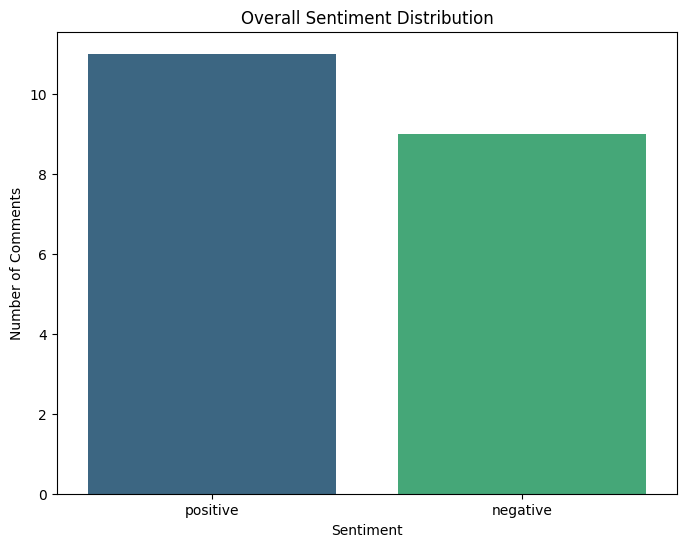

In [34]:

plt.figure(figsize=(8, 6))
sns.countplot(x='predicted_sentiment', data=df, palette='viridis')
plt.title('Overall Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.show()

/tmp/ipykernel_1609/4200875478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dominant_topic', data=df, palette='plasma')


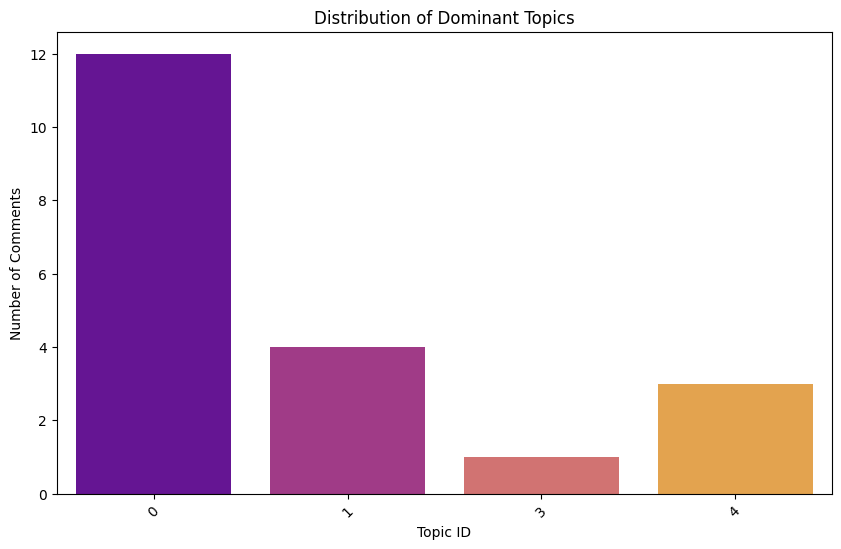

In [35]:

plt.figure(figsize=(10, 6))
sns.countplot(x='dominant_topic', data=df, palette='plasma')
plt.title('Distribution of Dominant Topics')
plt.xlabel('Topic ID')
plt.ylabel('Number of Comments')
plt.xticks(rotation=45)
plt.show()

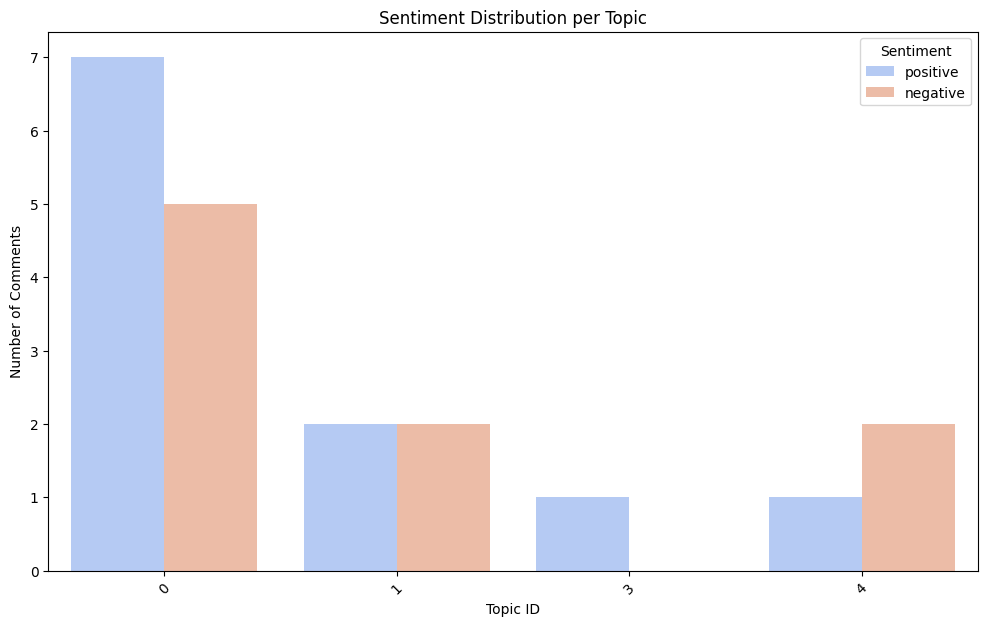


Example Positive Comments for Topic 0:


,text,predicted_sentiment
0,This new smartphone is absolutely amazing! The...,positive
2,The marketing campaign for the new soda is so ...,positive
4,"Just tried the new coffee flavor, it's surpris...",positive
8,Excited for the upcoming game release! Pre-ord...,positive
10,Loving the new eco-friendly packaging! Great s...,positive


In [36]:
plt.figure(figsize=(12, 7))
sns.countplot(x='dominant_topic', hue='predicted_sentiment', data=df, palette='coolwarm')
plt.title('Sentiment Distribution per Topic')
plt.xlabel('Topic ID')
plt.ylabel('Number of Comments')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.show()


print("\nExample Positive Comments for Topic 0:")
display(df[(df['dominant_topic'] == 0) & (df['predicted_sentiment'] == 'positive')][['text', 'predicted_sentiment']].head())